# Specific Analisis

In [1]:
# Cell 1: Environment Setup and Data Import
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set academic seaborn theme
sns.set_theme(style="whitegrid")

# Load benchmark dataset (replace filename with your actual CSV path)
df = pd.read_csv("benchmark_granular_workflow.csv")

# Verify data import
print("Dataset imported successfully.")
print(f"Total rows: {len(df)}, Columns: {list(df.columns)}")
df.head(6)

Dataset imported successfully.
Total rows: 6000, Columns: ['sample', 'n_nets', 'perfil', 't_p1', 't_p2', 't_p3', 'total_t', 'mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb', 'mem_total_kb', 'n_attractors', 'n_pairs', 'n_fields']


,sample,n_nets,perfil,t_p1,t_p2,t_p3,total_t,mem_p1_kb,mem_p2_kb,mem_p3_kb,mem_total_kb,n_attractors,n_pairs,n_fields
0,1,8,seq,0.491197,0.000885,0.000835,0.492917,180.286133,7.759766,11.403320,180.286133,17,21,1
1,1,8,par,0.275924,0.028838,0.149072,0.453834,539.638672,47.037109,46.216797,539.638672,17,21,1
2,1,8,weights,0.255673,0.030166,0.151996,0.437834,170.463867,40.589844,44.548828,170.463867,17,21,1
3,1,8,cpp_seq,0.005461,0.000063,0.000074,0.005598,0.000000,0.000000,0.000000,0.000000,17,21,1
4,1,8,cpp_par,0.003148,0.000028,0.000070,0.003247,0.000000,0.000000,0.000000,0.000000,17,21,1
5,1,8,cpp_adv,0.003377,0.000038,0.000073,0.003489,0.000000,0.000000,0.000000,0.000000,17,21,1


In [2]:
# Cell 2: Data Filtering (Isolating Python Weights vs. C++ Advanced)
# Head-to-head comparison for committee presentation
target_profiles = ['weights', 'cpp_adv']
df_head2head = df[df['perfil'].isin(target_profiles)].copy()

# Distinct academic color encoding: Blue for Python Weights, Red for C++ Advanced
head2head_palette = {
    'weights': '#1f77b4',  # Academic Blue
    'cpp_adv': '#d62728'   # Academic Red
}

print(f"Filtered subset size: {len(df_head2head)} records")
print(df_head2head['perfil'].value_counts())

Filtered subset size: 2000 records
perfil
weights    1000
cpp_adv    1000
Name: count, dtype: int64


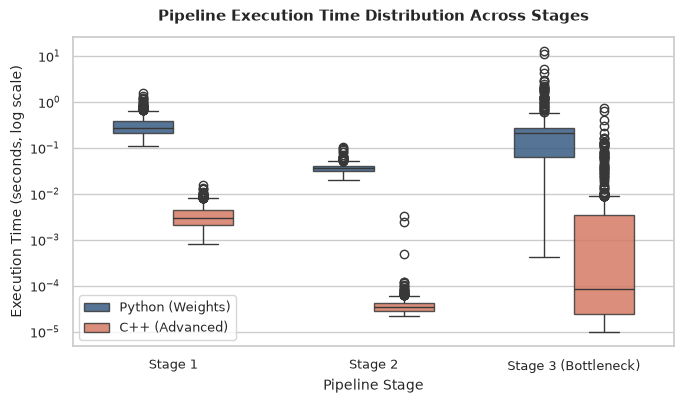

In [3]:
# Combined Multi-Stage Log-Scale Boxplot with Professional Academic Palette
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reshape the dataframe into a long format using pd.melt
df_melted = pd.melt(
    df_head2head,
    id_vars=['perfil'],
    value_vars=['t_p1', 't_p2', 't_p3'],
    var_name='Stage',
    value_name='Execution Time'
)

# 2. Map stage identifiers to clean, presentation-ready labels
stage_mapping = {
    't_p1': 'Stage 1',
    't_p2': 'Stage 2',
    't_p3': 'Stage 3 (Bottleneck)'
}
df_melted['Stage'] = df_melted['Stage'].map(stage_mapping)

# 3. Professional academic palette: Steel Blue and Warm Coral (Colorblind-friendly & high contrast)
academic_palette = ['#2B5C8F', '#E76F51']

# 4. Create the consolidated figure
fig, ax = plt.subplots(figsize=(7.0, 4.2))

sns.boxplot(
    data=df_melted, 
    x='Stage', 
    y='Execution Time', 
    hue='perfil',
    palette=academic_palette, 
    width=0.6, 
    boxprops=dict(alpha=0.85), 
    ax=ax
)

ax.set_yscale('log')
ax.set_title('Pipeline Execution Time Distribution Across Stages', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Pipeline Stage', fontsize=10)
ax.set_ylabel('Execution Time (seconds, log scale)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Legend placed at the lower left in a single column
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=['Python (Weights)', 'C++ (Advanced)'], 
    loc='lower left', 
    ncol=1, 
    fontsize=9, 
    frameon=True
)

plt.tight_layout()
plt.savefig("1_boxplot_velocity_all_stages.pdf", format='pdf', bbox_inches='tight')
plt.show()

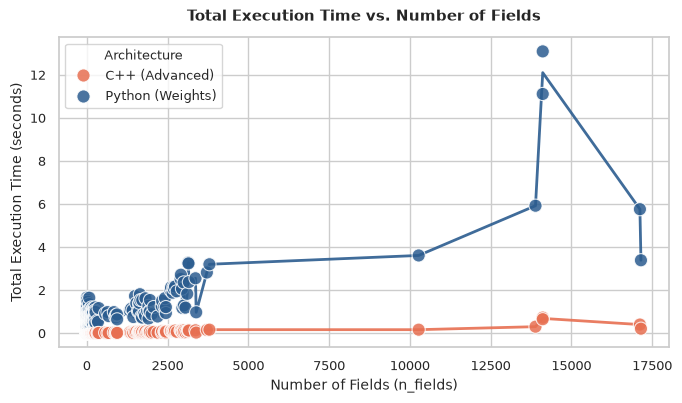

In [4]:
# Cell 6: Standalone Total Execution Time Comparison (Mapped Profiles & Explicit Palette)
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ordenamos por n_fields y hacemos una copia
df_sorted = df_head2head.sort_values('n_fields').copy()

# 2. Mapeamos los identificadores internos a etiquetas limpias y de publicación
profile_mapping = {
    'weights': 'Python (Weights)',
    'cpp_adv': 'C++ (Advanced)'
}
df_sorted['Profile'] = df_sorted['perfil'].map(profile_mapping)

# 3. Configuramos la figura con el tamaño exacto solicitado
fig, ax = plt.subplots(figsize=(7.0, 4.2))

# 4. Diccionario de colores alineado con las etiquetas mapeadas
palette_dict = {
    'Python (Weights)': '#2B5C8F',  # Azul Acero
    'C++ (Advanced)': '#E76F51'     # Coral Cálido
}

# 5. Dibujamos las líneas primero (zorder=1 para que queden de fondo)
sns.lineplot(
    data=df_sorted, x='n_fields', y='total_t', hue='Profile', 
    palette=palette_dict, legend=False, 
    errorbar=None, linewidth=2.0, alpha=0.9, ax=ax, zorder=1
)

# 6. Dibujamos los puntos encima (zorder=2 para que destaquen)
sns.scatterplot(
    data=df_sorted, x='n_fields', y='total_t', hue='Profile', 
    palette=palette_dict, s=90, 
    alpha=0.85, ax=ax, zorder=2
)

ax.set_title('Total Execution Time vs. Number of Fields', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=10)
ax.set_ylabel('Total Execution Time (seconds)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Leyenda limpia y sincronizada
ax.legend(title='Architecture', loc='upper left', frameon=True, fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("2_head2head_time_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

### Espace Analisis

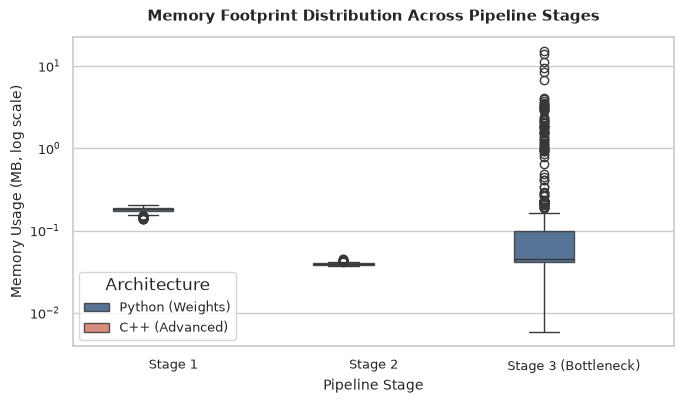

In [5]:
# Combined Multi-Stage Memory Footprint Boxplot using exact schema columns (mem_*_kb)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Reshape the dataframe into a long format using exact memory columns (converted to MB for clarity)
df_memory_melted = pd.melt(
    df_head2head,
    id_vars=['perfil'],
    value_vars=['mem_p1_kb', 'mem_p2_kb', 'mem_p3_kb'],
    var_name='Stage',
    value_name='Memory Usage (MB)'
)
df_memory_melted['Memory Usage (MB)'] = df_memory_melted['Memory Usage (MB)'] / 1024.0

# 2. Map stage identifiers to clean, presentation-ready labels
stage_mapping = {
    'mem_p1_kb': 'Stage 1',
    'mem_p2_kb': 'Stage 2',
    'mem_p3_kb': 'Stage 3 (Bottleneck)'
}
df_memory_melted['Stage'] = df_memory_melted['Stage'].map(stage_mapping)

# 3. Explicit profile mapping to match the academic legend
profile_mapping = {
    'weights': 'Python (Weights)',
    'cpp_adv': 'C++ (Advanced)'
}
df_memory_melted['Profile'] = df_memory_melted['perfil'].map(profile_mapping).fillna(df_memory_melted['perfil'])

# 4. Professional academic palette: Steel Blue and Warm Coral
academic_palette = ['#2B5C8F', '#E76F51']
profile_order = ['Python (Weights)', 'C++ (Advanced)']

# 5. Create the consolidated figure with strict single-column dimensions
fig, ax = plt.subplots(figsize=(7.0, 4.2))

sns.boxplot(
    data=df_memory_melted, 
    x='Stage', 
    y='Memory Usage (MB)', 
    hue='Profile',
    hue_order=profile_order,
    palette=academic_palette, 
    width=0.6, 
    boxprops=dict(alpha=0.85), 
    ax=ax
)

ax.set_yscale('log')
ax.set_title('Memory Footprint Distribution Across Pipeline Stages', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Pipeline Stage', fontsize=10)
ax.set_ylabel('Memory Usage (MB, log scale)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Legend placed at the lower left in a single column
handles, labels = ax.get_legend_handles_labels()
ax.legend(
    handles=handles, 
    labels=profile_order, 
    loc='lower left', 
    ncol=1, 
    fontsize=9, 
    frameon=True,
    title='Architecture'
)

plt.tight_layout()
plt.savefig("3_boxplot_space_stages_log.pdf", format='pdf', bbox_inches='tight')
plt.show()

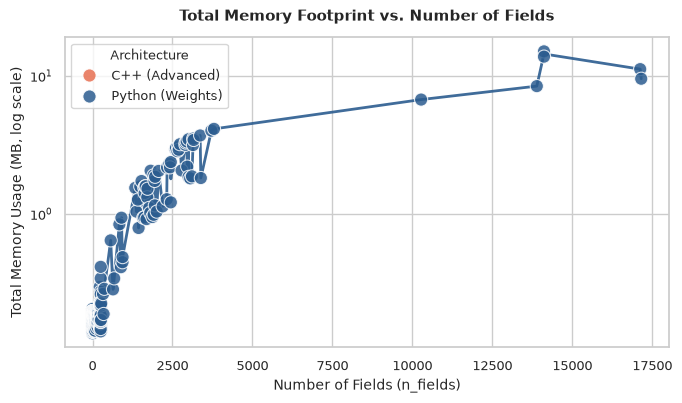

In [6]:
# Cell: Standalone Total Memory Footprint Comparison vs. Number of Fields
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Sort by n_fields and make a copy
df_sorted = df_head2head.sort_values('n_fields').copy()

# 2. Map internal profiles to publication-ready labels
profile_mapping = {
    'weights': 'Python (Weights)',
    'cpp_adv': 'C++ (Advanced)'
}
df_sorted['Profile'] = df_sorted['perfil'].map(profile_mapping)

# 3. Convert total memory from KB to MB for cleaner presentation
df_sorted['mem_total_mb'] = df_sorted['mem_total_kb'] / 1024.0

# 4. Configure figure with precise single-column dimensions
fig, ax = plt.subplots(figsize=(7.0, 4.2))

# 5. Color palette dictionary aligned with mapped profile labels
palette_dict = {
    'Python (Weights)': '#2B5C8F',  # Steel Blue
    'C++ (Advanced)': '#E76F51'     # Warm Coral
}

# 6. Draw lines first (zorder=1 to keep in background)
sns.lineplot(
    data=df_sorted, x='n_fields', y='mem_total_mb', hue='Profile', 
    palette=palette_dict, legend=False, 
    errorbar=None, linewidth=2.0, alpha=0.9, ax=ax, zorder=1
)

# 7. Draw scatter points on top (zorder=2 for visual prominence)
sns.scatterplot(
    data=df_sorted, x='n_fields', y='mem_total_mb', hue='Profile', 
    palette=palette_dict, s=90, 
    alpha=0.85, ax=ax, zorder=2
)

ax.set_yscale('log')
ax.set_title('Total Memory Footprint vs. Number of Fields', fontweight='bold', pad=12, fontsize=11)
ax.set_xlabel('Number of Fields (n_fields)', fontsize=10)
ax.set_ylabel('Total Memory Usage (MB, log scale)', fontsize=10)
ax.tick_params(axis='both', labelsize=9)

# Clean and synchronized legend
ax.legend(title='Architecture', loc='upper left', frameon=True, fontsize=9, title_fontsize=9)

plt.tight_layout()
plt.savefig("4_head2head_space_total.pdf", format='pdf', bbox_inches='tight')
plt.show()

In [7]:
# Cell 8: Master Summary Table Generation & Export (Time and Space)
import pandas as pd
import numpy as np
from IPython.display import display

# 1. Extraer perfiles exactos (weights vs cpp_adv)
df_py = df_head2head[df_head2head['perfil'] == 'weights']
df_cpp = df_head2head[df_head2head['perfil'] == 'cpp_adv']

# 2. Computar medianas globales (Tiempo en segundos, Memoria en MB)
py_time = df_py['total_t'].median()
cpp_time = df_cpp['total_t'].median()

py_bot = df_py['t_p3'].median()
cpp_bot = df_cpp['t_p3'].median()

py_mem = df_py['mem_total_kb'].median() / 1024.0
cpp_mem = df_cpp['mem_total_kb'].median() / 1024.0

# 3. Construir la matriz de resultados usando la nomenclatura correcta
summary_data = [
    {
        'Key Metric': 'Overall Execution Time',
        'Python (Weights)': f"{py_time:.4f} s",
        'C++ (Advanced)': f"{cpp_time:.4f} s",
        'Achievement': f"{py_time/cpp_time:.2f}x Speedup"
    },
    {
        'Key Metric': 'Bottleneck Time (Stage 3)',
        'Python (Weights)': f"{py_bot:.4f} s",
        'C++ (Advanced)': f"{cpp_bot:.4f} s",
        'Achievement': f"{py_bot/cpp_bot:.2f}x Speedup"
    },
    {
        'Key Metric': 'Total Memory Footprint',
        'Python (Weights)': f"{py_mem:.2f} MB",
        'C++ (Advanced)': f"{cpp_mem:.2f} MB",
        'Achievement': f"{(1 - cpp_mem/py_mem)*100:.1f}% Reduction"
    }
]

df_summary = pd.DataFrame(summary_data)

# 4. MOSTRAR EN EL NOTEBOOK (Vista renderizada y limpia)
print("=" * 85)
print(" 🏆 MASTER SUMMARY: TIME & SPACE ACHIEVEMENTS")
print("=" * 85)
display(df_summary)
print("=" * 85)

# 5. EXPORTAR A LATEX (Añadiendo formato matemático y negritas)
df_latex = df_summary.copy()
# Reemplazar 'x' por '\times' y '%' por '\%' solo para LaTeX
df_latex['Achievement'] = df_latex['Achievement'].str.replace('x', r'$\times$').str.replace('%', r'\%')
# Poner los nombres de las columnas en negrita
df_latex.columns = [rf'\textbf{{{col}}}' for col in df_latex.columns]

# Actualización del caption para reflejar 'Python (Weights)'
latex_table = df_latex.to_latex(
    index=False,
    escape=False,
    column_format='lllc',
    caption='Summary of primary performance and memory footprint achievements comparing the Python (Weights) implementation against the C++ (Advanced) architecture.',
    label='tab:master_summary'
)

# 6. Guardar siguiendo la nomenclatura estricta
with open("5_summary_table_results.tex", "w") as f:
    f.write(latex_table)

print("✅ Archivo '5_summary_table_results.tex' generado con éxito.")

 🏆 MASTER SUMMARY: TIME & SPACE ACHIEVEMENTS


,Key Metric,Python (Weights),C++ (Advanced),Achievement
0,Overall Execution Time,0.5331 s,0.0043 s,124.61x Speedup
1,Bottleneck Time (Stage 3),0.2159 s,0.0001 s,2482.05x Speedup
2,Total Memory Footprint,0.18 MB,0.00 MB,100.0% Reduction


✅ Archivo '5_summary_table_results.tex' generado con éxito.


In [8]:
# Cell 9: Maximum Values & Worst-Case Scenario Summary
import pandas as pd
from IPython.display import display

# 1. Asegurar la separación correcta de perfiles
df_py = df_head2head[df_head2head['perfil'] == 'weights']
df_cpp = df_head2head[df_head2head['perfil'] == 'cpp_adv']

# 2. Calcular los valores máximos absolutos (Peor de los casos y límite explorado)
py_max_time = df_py['total_t'].max()
cpp_max_time = df_cpp['total_t'].max()

py_max_mem = df_py['mem_total_kb'].max() / 1024.0
cpp_max_mem = df_cpp['mem_total_kb'].max() / 1024.0

py_max_fields = df_py['n_fields'].max()
cpp_max_fields = df_cpp['n_fields'].max()

# 3. Construir la estructura de la tabla
max_data = [
    {
        'Maximum Metric': 'Peak Execution Time',
        'Python (Weights)': f"{py_max_time:.4f} s",
        'C++ (Advanced)': f"{cpp_max_time:.4f} s",
        'Observation': f"{py_max_time/cpp_max_time:.2f}x Speedup at peak"
    },
    {
        'Maximum Metric': 'Peak Memory Footprint',
        'Python (Weights)': f"{py_max_mem:.2f} MB",
        'C++ (Advanced)': f"{cpp_max_mem:.2f} MB",
        'Observation': f"{(1 - cpp_max_mem/py_max_mem)*100:.1f}% Reduction at peak"
    },
    {
        'Maximum Metric': 'Max Attractor Fields Found',
        'Python (Weights)': f"{int(py_max_fields):,}",
        'C++ (Advanced)': f"{int(cpp_max_fields):,}",
        'Observation': "Exact Match (Validates Logic)" if py_max_fields == cpp_max_fields else "Mismatch Check Needed!"
    }
]

df_max = pd.DataFrame(max_data)

# 4. MOSTRAR EN EL NOTEBOOK (Vista renderizada y limpia)
print("=" * 90)
print(" 🚨 WORST-CASE SCENARIO & PEAK DISCOVERIES SUMMARY")
print("=" * 90)
display(df_max)
print("=" * 90)

# 5. EXPORTAR A LATEX (Añadiendo formato matemático y negritas)
df_max_latex = df_max.copy()
# Reemplazar 'x' por '\times' y '%' por '\%' para LaTeX
df_max_latex['Observation'] = df_max_latex['Observation'].str.replace('x', r'$\times$').str.replace('%', r'\%')
# Nombres de las columnas en negrita
df_max_latex.columns = [rf'\textbf{{{col}}}' for col in df_max_latex.columns]

# Generar la tabla con el caption ajustado
latex_max_table = df_max_latex.to_latex(
    index=False,
    escape=False,
    column_format='lllc',
    caption='Summary of absolute maximum observed values (worst-case execution time and memory footprint) and peak attractor fields discovered, comparing Python (Weights) and C++ (Advanced).',
    label='tab:max_values'
)

# 6. Guardar siguiendo la nomenclatura estricta del experimento
with open("6_max_values_table.tex", "w") as f:
    f.write(latex_max_table)

print("✅ Archivo '6_max_values_table.tex' generado con éxito.")

 🚨 WORST-CASE SCENARIO & PEAK DISCOVERIES SUMMARY


,Maximum Metric,Python (Weights),C++ (Advanced),Observation
0,Peak Execution Time,13.0939 s,0.7299 s,17.94x Speedup at peak
1,Peak Memory Footprint,15.10 MB,0.00 MB,100.0% Reduction at peak
2,Max Attractor Fields Found,"17,152","17,152",Exact Match (Validates Logic)


✅ Archivo '6_max_values_table.tex' generado con éxito.
